In [1]:
import os
import copy
import torch
torch.cuda.empty_cache()  # 释放未使用的缓存
from pathlib import Path
from MVCL.MVInfoNCE.config import set_arg
from MVCL.MVInfoNCE.data import *
from MVCL.MVInfoNCE.utils import *
from MVCL.MVInfoNCE.MVInfoNCE import *
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score


In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/stereo_seq_MouseOlfactoryBulb')
result_path = "/home/ZHX/code111/GraphST-main/results/MVInfoNCE2_result/"
#设置参数
opt = set_arg()
arg = opt.parse_args(['--n_domain', '7','--radius', '50','--n_refine','25'])
print(arg)

当前路径： /home/ZHX/code111/GraphST-main/MVCL2/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=64, log_step=10, lr=0.001, n_domain=7, n_refine=25, radius=50, seed=0, temp=0.05, weight_decay=0.0001)


In [3]:
sample_name = 'stereo-seq_MOB'
counts_file = os.path.join(data_root, 'RNA_counts.tsv')
coor_file = os.path.join(data_root, 'position.tsv')

In [4]:
counts = pd.read_csv(counts_file, sep='\t', index_col=0)
coor_df = pd.read_csv(coor_file, sep='\t')
print(counts.shape, coor_df.shape)

(27106, 19527) (19527, 3)


In [5]:
counts.columns = ['Spot_'+str(x) for x in counts.columns]
coor_df.index = coor_df['label'].map(lambda x: 'Spot_'+str(x))
coor_df = coor_df.loc[:, ['x','y']]
coor_df.head()

,x,y
label,,
Spot_1,12555.007833,6307.537859
Spot_2,12623.666667,6297.166667
Spot_3,12589.567164,6302.552239
Spot_4,12642.495050,6307.386139
Spot_5,13003.333333,6307.990991


In [6]:
adata = sc.AnnData(counts.T)
adata.X = csr_matrix(adata.X)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 19527 × 27106


In [7]:
print(coor_df)

                       x             y
label                                 
Spot_1      12555.007833   6307.537859
Spot_2      12623.666667   6297.166667
Spot_3      12589.567164   6302.552239
Spot_4      12642.495050   6307.386139
Spot_5      13003.333333   6307.990991
...                  ...           ...
Spot_19888  14656.130435  12156.869565
Spot_19889  10717.785714  12189.571429
Spot_19890  10872.913580  12190.123457
Spot_19891  11628.769231  12191.846154
Spot_19892  13984.760000  12191.240000

[19527 rows x 2 columns]


In [8]:
coor_df = coor_df.loc[adata.obs_names, ['y', 'x']]
adata.obsm["spatial"] = coor_df.to_numpy()
sc.pp.calculate_qc_metrics(adata, inplace=True)
print(adata)

AnnData object with n_obs × n_vars = 19527 × 27106
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'


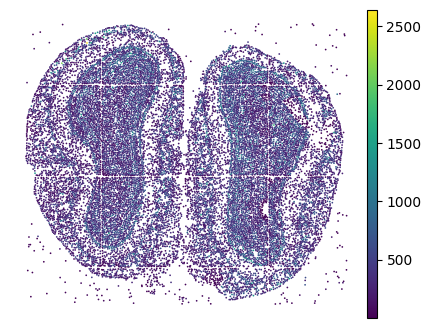

In [9]:
out_path = os.path.join(result_path , sample_name)
# 检查文件夹是否存在，如果不存在则创建文件夹
if not os.path.exists(out_path):
    os.makedirs(out_path)
plt.rcParams["figure.figsize"] = (5,4)
sc.pl.embedding(adata, basis="spatial", color="n_genes_by_counts", show=False)
plt.title("")
plt.axis('off')
plt.savefig(os.path.join(out_path,"stereo_MOB01.png"))


In [10]:
used_barcode = pd.read_csv(os.path.join(data_root,'used_barcodes.txt'), sep='\t', header=None)
used_barcode = used_barcode[0]
adata = adata[used_barcode,]
print(adata)

View of AnnData object with n_obs × n_vars = 19109 × 27106
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'


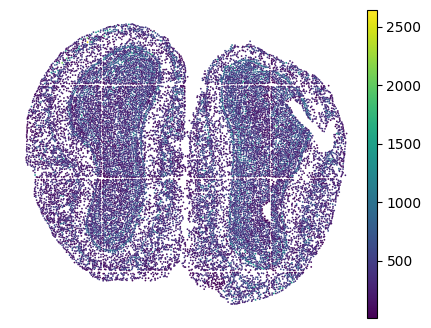

In [11]:
plt.rcParams["figure.figsize"] = (5,4)
sc.pl.embedding(adata, basis="spatial", color="n_genes_by_counts", show=False)
plt.title("")
plt.axis('off')
plt.savefig(os.path.join(out_path,"stereo_MOB02.png"))


In [12]:
sc.pp.filter_genes(adata, min_cells=50)
print('After flitering: ', adata.shape)

After flitering:  (19109, 14376)


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number


In [13]:
#preprocessing
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("=============预处理后{}切片信息===============".format(sample_name))
print(adata)


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


=============预处理后stereo-seq_MOB切片信息===============
AnnData object with n_obs × n_vars = 19109 × 14376
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial'


In [14]:
import gc
gc.collect()  # 强制垃圾回收

14254

In [15]:


# train model
adata = train(adata,arg)
print("Completion of training")

# clustering
adata = mclust_R(adata, arg.n_domain,used_obsm='MVInfoNCE' )
# adata = mclust_R(adata, arg.n_domain,used_obsm='MVInfoNCE' ,refine=True, n_refine=arg.n_refine)

# # filter out NA nodes
# adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
# ARI = adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground Truth'])
# print('ARI = %.4f' %ARI)
# adata.uns['ARI']=ARI

spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (19109, 3000)
AnnData object with n_obs × n_vars = 19109 × 14376
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'graph_neigh1', 'graph_neigh2', 'adj1', 'adj2', 'feat', 'feat_a', 'f_graph_neigh', 'fadj'
Begin to train ST data...


  0%|          | 0/1000 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.72 GiB. GPU 1 has a total capacity of 23.64 GiB of which 228.25 MiB is free. Process 3103809 has 11.45 GiB memory in use. Including non-PyTorch memory, this process has 11.96 GiB memory in use. Of the allocated memory 11.39 GiB is allocated by PyTorch, and 146.07 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='MVInfoNCE')
sc.tl.umap(adata)
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.embedding(adata, basis="spatial", color="mclust",s=10,  show=False, title='MVInfoNCE')
plt.axis('off')
plt.savefig(os.path.join(out_path,"{}_umap.png").format(sample_name))